In [30]:
from dataclasses import dataclass
import json
import numpy as np
import os
import random
import torch
from torch import optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

if not os.path.exists("./KuiSCIMA"):
    !git clone https://github.com/SuziAI/KuiSCIMA.git
if not os.path.exists("./gui-tools"):
    !git clone https://github.com/SuziAI/gui-tools.git

from data_extraction import *
from image_manipulation import *
from model import *
from suzipu import *

# Model Metrics

In [31]:
total_dataset = open_suzipu_dataset("./TotalDataset/Music/")
total_dataset = get_cropped_dataset(total_dataset)

## Normalizes the dataset to have mean 0 and standard deviation of 1
#mean_list = torch.Tensor([torch.Tensor(entry["image"]).mean() for entry in total_dataset])/255
#mean = mean_list.mean()
#std = mean_list.std()

def normalize():
    return transforms.Normalize(mean=0.7102, std=0.0914)

def get_train_transforms(image_size=48):
    target_shrink = image_size - 8
    target_paste = image_size
    train_transforms = transforms.Compose([
        erode(percentage=0.2), # causes the notation to be thicker
        dilate(percentage=0.2), # causes the notation to be thinner
        transforms.ToTensor(), # convert from uint8 to [0, 1]
        shrink(is_random=True, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        salt_and_pepper(percentage=0.8), # introduces salt-and-pepper-noise
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        transforms.RandomRotation(degrees=(-9, 9)), # randomly rotate between -12 and 12 degrees
        #lambda img: transforms.functional.invert(img), # inverts image to original color scheme
        normalize(), # normalize mean and variance
    ])
    return train_transforms


def get_validation_transforms(image_size=48):
    target_shrink = image_size - 8
    target_paste = image_size
    validation_transforms = transforms.Compose([
        transforms.ToTensor(),
        shrink(is_random=False, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        normalize(), # normalize mean and variance
    ])
    return validation_transforms


def get_test_transforms(image_size=48):
    return get_validation_transforms(image_size=image_size)

transformations = {
    "train": get_train_transforms,
    "validation": get_validation_transforms,
    "test": get_test_transforms
}

total_dataloaders = get_all_dataloaders(total_dataset, test_edition="shanghai", transformations=transformations)

In [32]:
def double_test(pitch_model, secondary_model, total_loader):  

    pitch_model.eval()
    secondary_model.eval()
        
    # Train the model
    total_step = len(total_loader)
    
    pred_y_pitch = []
    pred_y_secondary = []
    full_labels_pitch = []
    full_labels_secondary = []
    
    is_simple_full = []
        
    for i, (images, labels, is_simple) in enumerate(total_loader["test"]):
        
        # gives batch data, normalize x when iterate train_loader
        b_x = Variable(images)   # batch x
       
        b_y_pitch = torch.Tensor([label for label in labels["pitch"] ])

        b_y_secondary = torch.Tensor([label for label in labels["secondary"]])

        output_pitch = pitch_model(b_x)
        output_secondary = secondary_model(b_x)

        pred_y_pitch += torch.argmax(output_pitch, dim=1)
        pred_y_secondary += torch.argmax(output_secondary, dim=1)
        
        
        full_labels_pitch += b_y_pitch
        full_labels_secondary += b_y_secondary
    
    full_labels = torch.stack((torch.Tensor(full_labels_pitch), torch.Tensor(full_labels_secondary)))
    pred_y = torch.stack((torch.Tensor(pred_y_pitch), torch.Tensor(pred_y_secondary)))

    columnwise_equal = torch.all(full_labels == pred_y, dim=0)
    #print(columnwise_equal)
    
    total_accuracy = columnwise_equal.sum() / float(len(columnwise_equal))

    print ('    Acc.(Total): {:.2f}%,'.format(total_accuracy*100))
    
    return total_accuracy, full_labels, pred_y

In [33]:
def get_best_model(label_type, test_edition):
        num_classes = 11 if "pitch" in label_type else 7
        model = CnnModel(num_classes)
        max_validation = 0
        for idx in range(10):
            path = f"./suzipu_models/{test_edition}-{label_type}-{idx}.std"
            file = torch.load(path, map_location=torch.device('cpu'))
            validation = file["val_accuracies"][-1]
            if validation > max_validation:
                max_validation = validation
                max_validation_test = file["test_accuracies"][-1]
                model.load_state_dict(file["state_dict"])

        return model, max_validation, max_validation_test

test_edition = "shanghai"
total_dataloaders = get_all_dataloaders(total_dataset, test_edition=test_edition, image_size=48, transformations=transformations)
pitch_model, pitch_validation, pitch_test = get_best_model("pitch_balanced", test_edition)
secondary_model, secondary_validation, secondary_test = get_best_model("secondary_balanced", test_edition)

acc, ground_truth, prediction = double_test(pitch_model, secondary_model, total_dataloaders["full"])

/tmp/ipykernel_11146/3362103144.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(path, map_location=torch.device('cpu'))


    Acc.(Total): 92.91%,


In [137]:
# convert pitch/secondary combinations to composite classes
ground_truth_pitch = ground_truth[0]
ground_truth_secondary = ground_truth[1]
ground_truth_classes = np.array([individual_labels_to_class(int(pitch), int(secondary)) for pitch, secondary in ground_truth.t()])

prediction_pitch = prediction[0]
prediction_secondary = prediction[1]
prediction_classes = np.array([individual_labels_to_class(int(pitch), int(secondary)) for pitch, secondary in prediction.t()])

print(ground_truth_classes.max())

75


[[ 78   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   0   0   0]
 [  0  67   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  0   0 114   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  0   0   0 120   0   0   0   0   0   0  

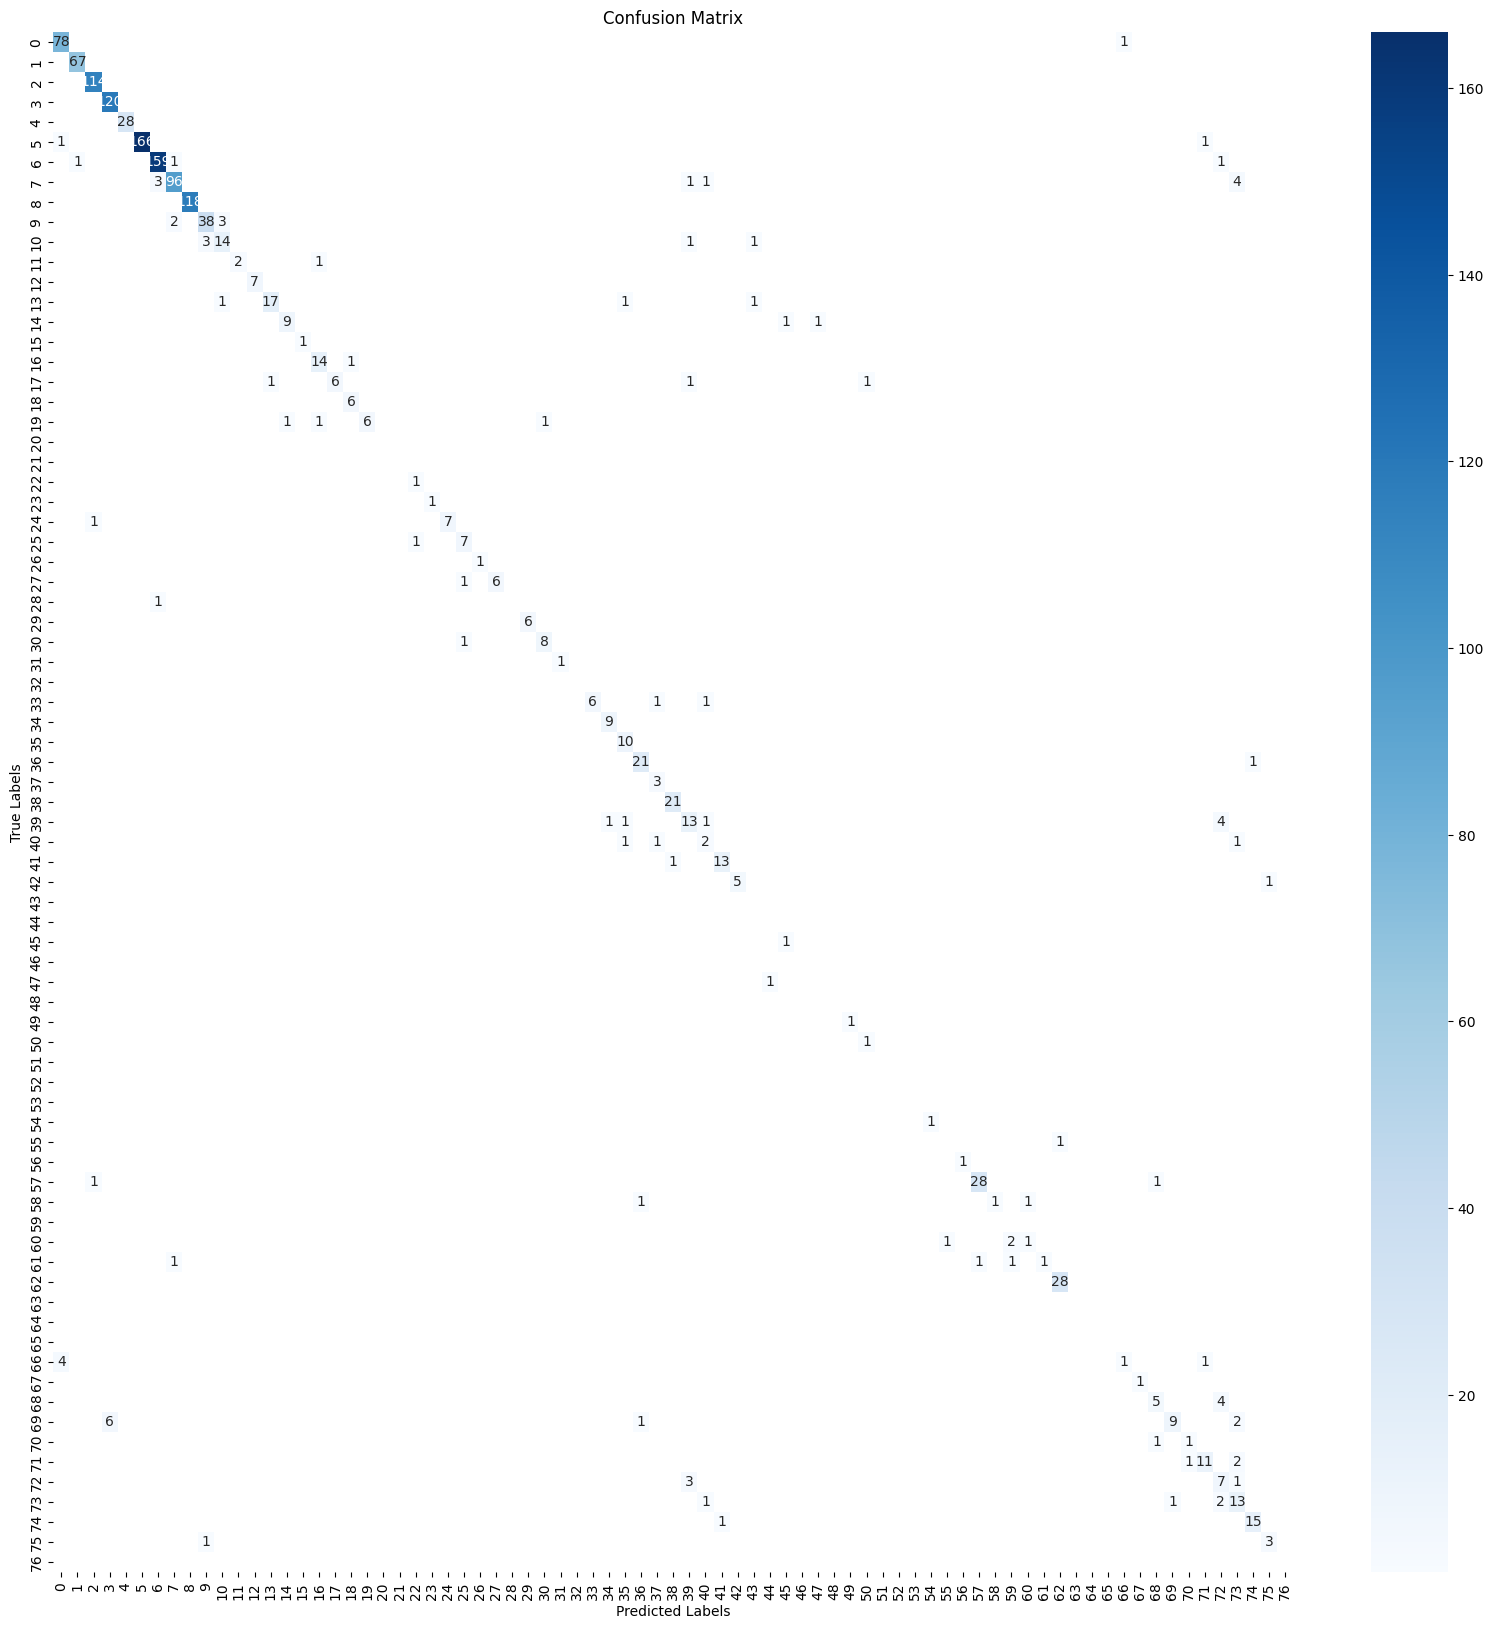

In [184]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(ground_truth, predictions, class_labels=None):
    cm = confusion_matrix(ground_truth, predictions, labels=range(len(class_labels)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, cbar=True, mask=(cm == 0))
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    return cm

def classification_metrics(ground_truth, predictions, class_labels=None):
    if class_labels is None:
        class_labels = np.unique(np.concatenate((ground_truth, predictions)))
    
    cm = confusion_matrix(ground_truth, predictions, labels=class_labels)
    
    
    if class_labels is None:
        class_labels = np.unique(np.concatenate((ground_truth, predictions)))
    
    tp = np.diagonal(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    tn = cm.sum() - (tp + fp + fn)

    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    precision = np.nan_to_num(tp / (tp + fp))
    recall = np.nan_to_num(tp / (tp + fn))
    f1_score = np.nan_to_num(2 * (precision * recall) / (precision + recall))

    per_class_acc = np.array(per_class_acc).reshape((7,11)).transpose()
    isnan_filter = np.ones_like(per_class_acc)
    isnan_filter[np.isnan(per_class_acc)] = per_class_acc[np.isnan(per_class_acc)]
    precision = np.array(precision).reshape((7,11)).transpose()
    recall = np.array(recall).reshape((7,11)).transpose()
    f1_score = np.array(f1_score).reshape((7,11)).transpose()

    sns.heatmap(f1_score*isnan_filter, annot=True, cmap='RdBu', fmt='.2f')

    return {
        "per_class": per_class_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1_score
    }

#plot_confusion_matrix(ground_truth[0], prediction[0], class_labels=range(11))
plt.figure(figsize=(20, 20))
cm = plot_confusion_matrix(ground_truth_classes, prediction_classes, class_labels=range(77))
np.set_printoptions(threshold=np.inf)
print(cm)

[[ 93   0   0   0   1   2   0   2   0   0   0]
 [  0  87   0   0   0   0   0   0   0   0   0]
 [  0   0 185   0   0   0   4   0   0   0   2]
 [  2   1   0 176   0   1   0   2   1   0   0]
 [  0   0   1   0  34   0   0   0   0   0   0]
 [  2   0   0   1   3 221   0   3   0   0   0]
 [  0   2   3   0   1   0 198   4   0   0   0]
 [  0   0   1   1   1   0   6 158   0   0   0]
 [  0   0   0   2   0   2   0   0 162   0   0]
 [  0   0   0   0   0   0   0   2   0  49   3]
 [  0   0   0   0   0   0   1   0   0   3  16]]


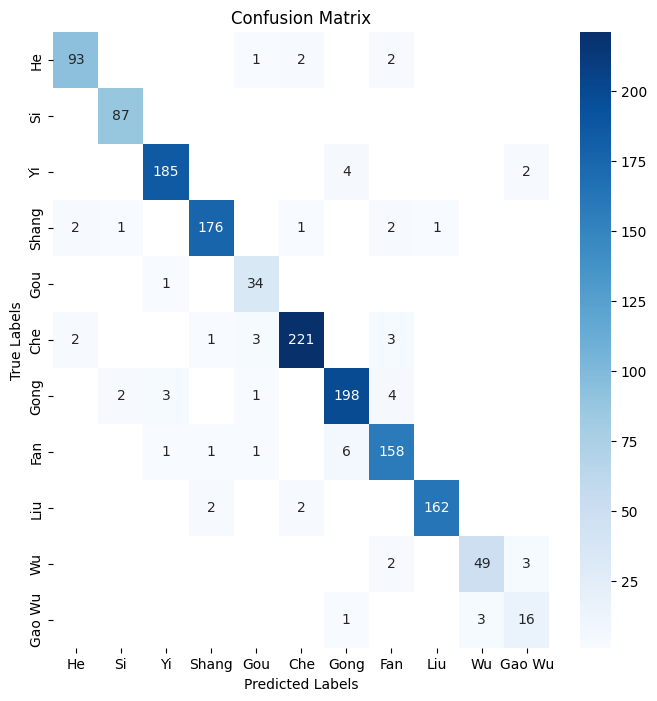

In [180]:
plt.figure(figsize=(8, 8))
cm = plot_confusion_matrix(ground_truth_pitch, prediction_pitch, class_labels=range(11))
plt.yticks(np.arange(11)+0.5, ["He", "Si", "Yi", "Shang", "Gou", "Che", "Gong", "Fan", "Liu", "Wu", "Gao Wu"])
plt.xticks(np.arange(11)+0.5, ["He", "Si", "Yi", "Shang", "Gou", "Che", "Gong", "Fan", "Liu", "Wu", "Gao Wu"])

print(cm)

([<matplotlib.axis.YTick at 0x78a6a8631e20>,
 [Text(0, 0.5, 'None'),
  Text(0, 1.5, 'Dadun'),
  Text(0, 2.5, 'Xiaozhu'),
  Text(0, 3.5, 'Dingzhu'),
  Text(0, 4.5, 'Dazhu'),
  Text(0, 5.5, 'Zhe'),
  Text(0, 6.5, 'Ye')])

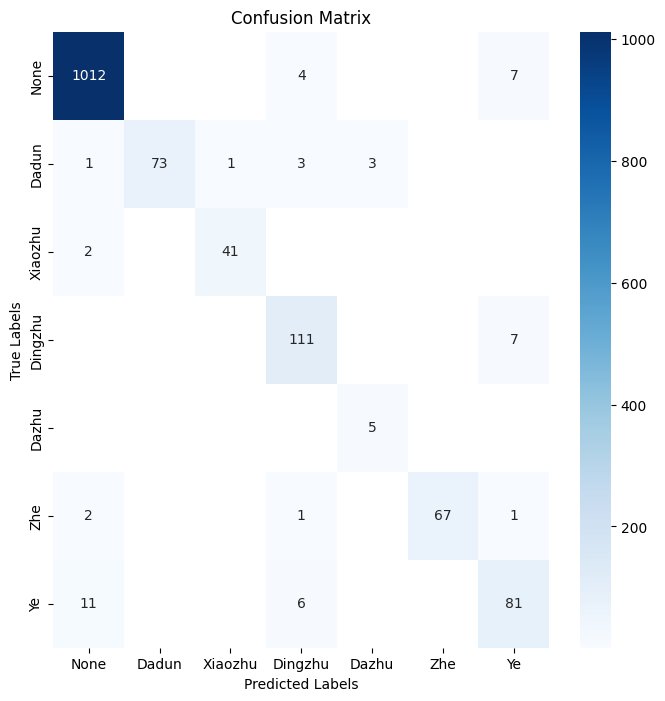

In [161]:
plt.figure(figsize=(8, 8))
plot_confusion_matrix(ground_truth_secondary, prediction_secondary, class_labels=range(7))
plt.xticks(np.arange(7)+0.5, ["None", "Dadun", "Xiaozhu", "Dingzhu", "Dazhu", "Zhe", "Ye"])
plt.yticks(np.arange(7)+0.5, ["None", "Dadun", "Xiaozhu", "Dingzhu", "Dazhu", "Zhe", "Ye"])

/tmp/ipykernel_11146/3215544939.py:26: RuntimeWarning: invalid value encountered in divide
  per_class_acc = cm.diagonal() / cm.sum(axis=1)
/tmp/ipykernel_11146/3215544939.py:27: RuntimeWarning: invalid value encountered in divide
  precision = np.nan_to_num(tp / (tp + fp))
/tmp/ipykernel_11146/3215544939.py:28: RuntimeWarning: invalid value encountered in divide
  recall = np.nan_to_num(tp / (tp + fn))
/tmp/ipykernel_11146/3215544939.py:29: RuntimeWarning: invalid value encountered in divide
  f1_score = np.nan_to_num(2 * (precision * recall) / (precision + recall))


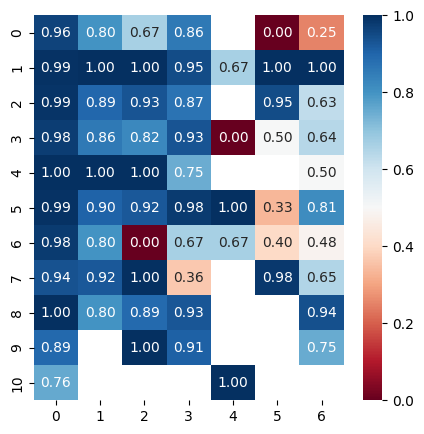

In [151]:
plt.figure(figsize=(5, 5))
classification_metrics(ground_truth_classes, prediction_classes, class_labels=range(77))
print()

# User Metrics

The best two users have annotated a complementary partition of the Shanghai MS. We aggregate these annotations and then compare with the confusion matrix of the mod

In [176]:
with open("study_statistics.json", "r") as file_handle:
    study_statistics = json.load(file_handle)

user_statistics = study_statistics["all"]
user_statistics_sorted = sorted(user_statistics, key=lambda x: x["total_accuracy"], reverse=True)
print(user_statistics_sorted[0]["total_accuracy"], len(user_statistics_sorted[0]["real_labels"]))
print(user_statistics_sorted[1]["total_accuracy"], len(user_statistics_sorted[1]["real_labels"]))

ground_truth_users = user_statistics_sorted[0]["real_labels"] + user_statistics_sorted[1]["real_labels"]
prediction_users = user_statistics_sorted[0]["user_labels"] + user_statistics_sorted[1]["user_labels"]

# replace NONE by None
for idx1 in range(len(ground_truth_users)):
    for idx2 in range(2):
        ground_truth_users[idx1][idx2] = ground_truth_users[idx1][idx2] if ground_truth_users[idx1][idx2] != "NONE" else None

# replace NONE by None
for idx1 in range(len(prediction_users)):
    for idx2 in range(2):
        prediction_users[idx1][idx2] = prediction_users[idx1][idx2] if prediction_users[idx1][idx2] != "NONE" else None


ground_truth_users_classes = np.array([properties_to_class(pitch, secondary) for pitch, secondary in ground_truth_users])
ground_truth_pitch_user = np.array([class_to_subclasses(cl)[0] for cl in ground_truth_users_classes])
ground_truth_secondary_user = np.array([class_to_subclasses(cl)[1] for cl in ground_truth_users_classes])

prediction_users_classes = np.array([properties_to_class(pitch, secondary) for pitch, secondary in prediction_users])
prediction_pitch_user = np.array([class_to_subclasses(cl)[0] for cl in prediction_users_classes])
prediction_secondary_user = np.array([class_to_subclasses(cl)[1] for cl in prediction_users_classes])

print("Combined human acc.:", (ground_truth_users_classes == prediction_users_classes).mean())

92.36111111111111 720
91.3769123783032 719
Combined human acc.: 0.9186935371785963


(77, 77)


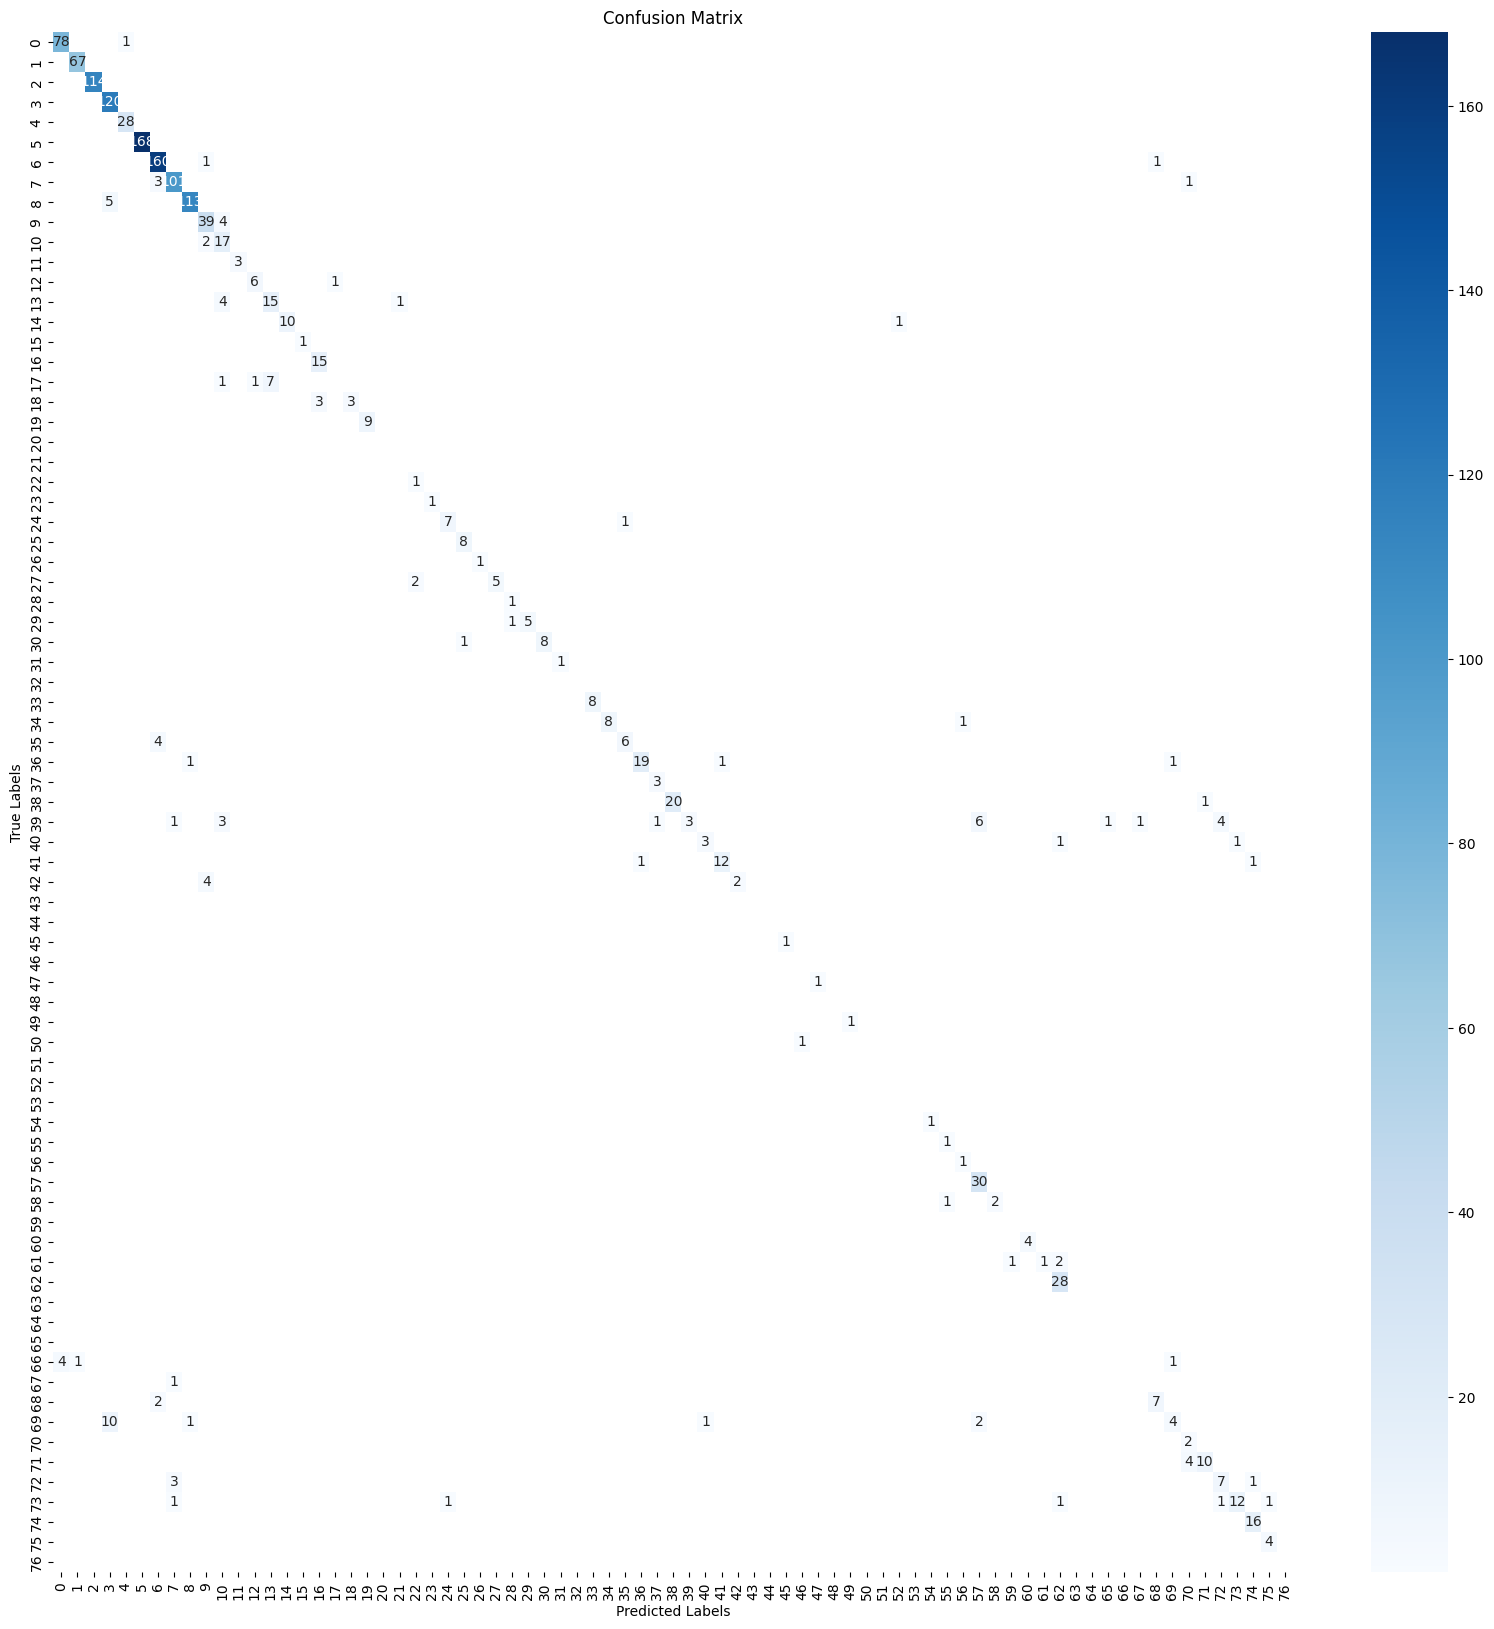

In [187]:
plt.figure(figsize=(20, 20))
cm = plot_confusion_matrix(ground_truth_users_classes, prediction_users_classes, class_labels=range(77))

[[ 95   1   0   1   1   0   0   0   0   0   0]
 [  0  85   0   0   0   0   1   1   0   0   0]
 [  0   0 180   0   0   0   6   0   0   0   5]
 [  1   0   2 175   0   0   0   1   4   0   0]
 [  0   0   0   0  35   0   0   0   0   0   0]
 [  2   0   0   0   4 224   0   0   0   0   0]
 [  0   2  15   0   2   0 176   6   1   1   5]
 [  0   0   1   0   1   3   5 156   0   1   0]
 [  0   0   0   7   0   0   0   0 159   0   0]
 [  0   0   0   0   0   0   0   0   0  50   4]
 [  0   0   0   0   0   0   0   0   0   2  18]]


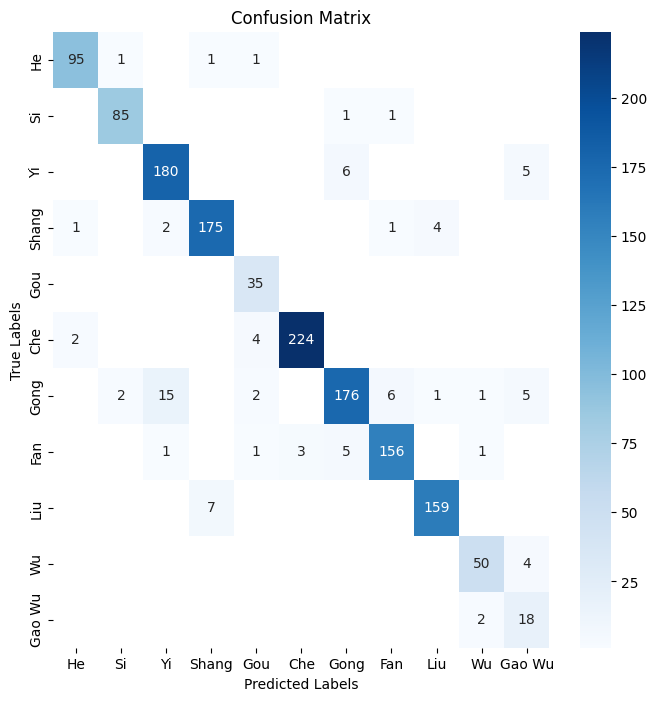

In [188]:
plt.figure(figsize=(8, 8))
cm = plot_confusion_matrix(ground_truth_pitch_user, prediction_pitch_user, class_labels=range(11))
plt.yticks(np.arange(11)+0.5, ["He", "Si", "Yi", "Shang", "Gou", "Che", "Gong", "Fan", "Liu", "Wu", "Gao Wu"])
plt.xticks(np.arange(11)+0.5, ["He", "Si", "Yi", "Shang", "Gou", "Che", "Gong", "Fan", "Liu", "Wu", "Gao Wu"])
print(cm)

([<matplotlib.axis.YTick at 0x78a6b6870aa0>,
 [Text(0, 0.5, 'None'),
  Text(0, 1.5, 'Dadun'),
  Text(0, 2.5, 'Xiaozhu'),
  Text(0, 3.5, 'Dingzhu'),
  Text(0, 4.5, 'Dazhu'),
  Text(0, 5.5, 'Zhe'),
  Text(0, 6.5, 'Ye')])

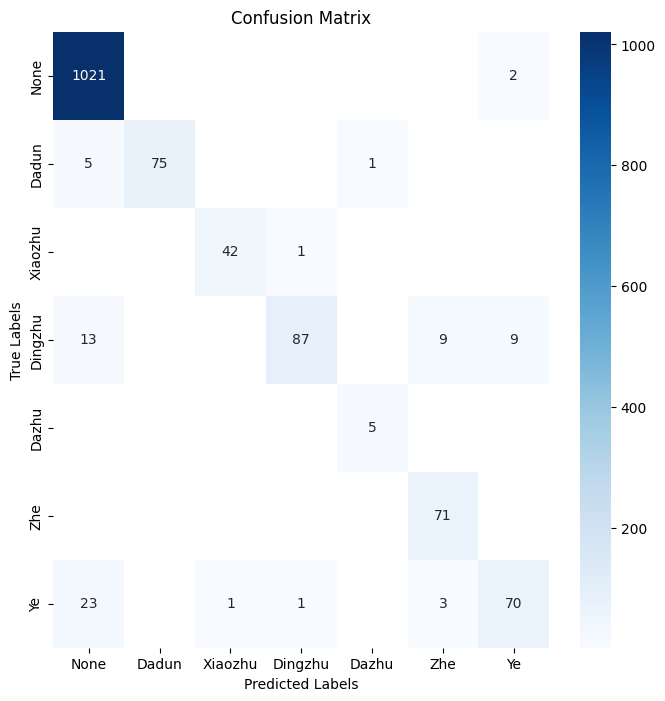

In [178]:
plt.figure(figsize=(8, 8))
plot_confusion_matrix(ground_truth_secondary_user, prediction_secondary_user, class_labels=range(7))
plt.xticks(np.arange(7)+0.5, ["None", "Dadun", "Xiaozhu", "Dingzhu", "Dazhu", "Zhe", "Ye"])
plt.yticks(np.arange(7)+0.5, ["None", "Dadun", "Xiaozhu", "Dingzhu", "Dazhu", "Zhe", "Ye"])

/tmp/ipykernel_11146/3160622226.py:27: RuntimeWarning: invalid value encountered in divide
  per_class_acc = cm.diagonal() / cm.sum(axis=1)
/tmp/ipykernel_11146/3160622226.py:28: RuntimeWarning: invalid value encountered in divide
  precision = np.nan_to_num(tp / (tp + fp))
/tmp/ipykernel_11146/3160622226.py:29: RuntimeWarning: invalid value encountered in divide
  recall = np.nan_to_num(tp / (tp + fn))
/tmp/ipykernel_11146/3160622226.py:30: RuntimeWarning: invalid value encountered in divide
  f1_score = np.nan_to_num(2 * (precision * recall) / (precision + recall))
/tmp/ipykernel_11146/3160622226.py:27: RuntimeWarning: invalid value encountered in divide
  per_class_acc = cm.diagonal() / cm.sum(axis=1)
/tmp/ipykernel_11146/3160622226.py:28: RuntimeWarning: invalid value encountered in divide
  precision = np.nan_to_num(tp / (tp + fp))
/tmp/ipykernel_11146/3160622226.py:29: RuntimeWarning: invalid value encountered in divide
  recall = np.nan_to_num(tp / (tp + fn))
/tmp/ipykernel_1114

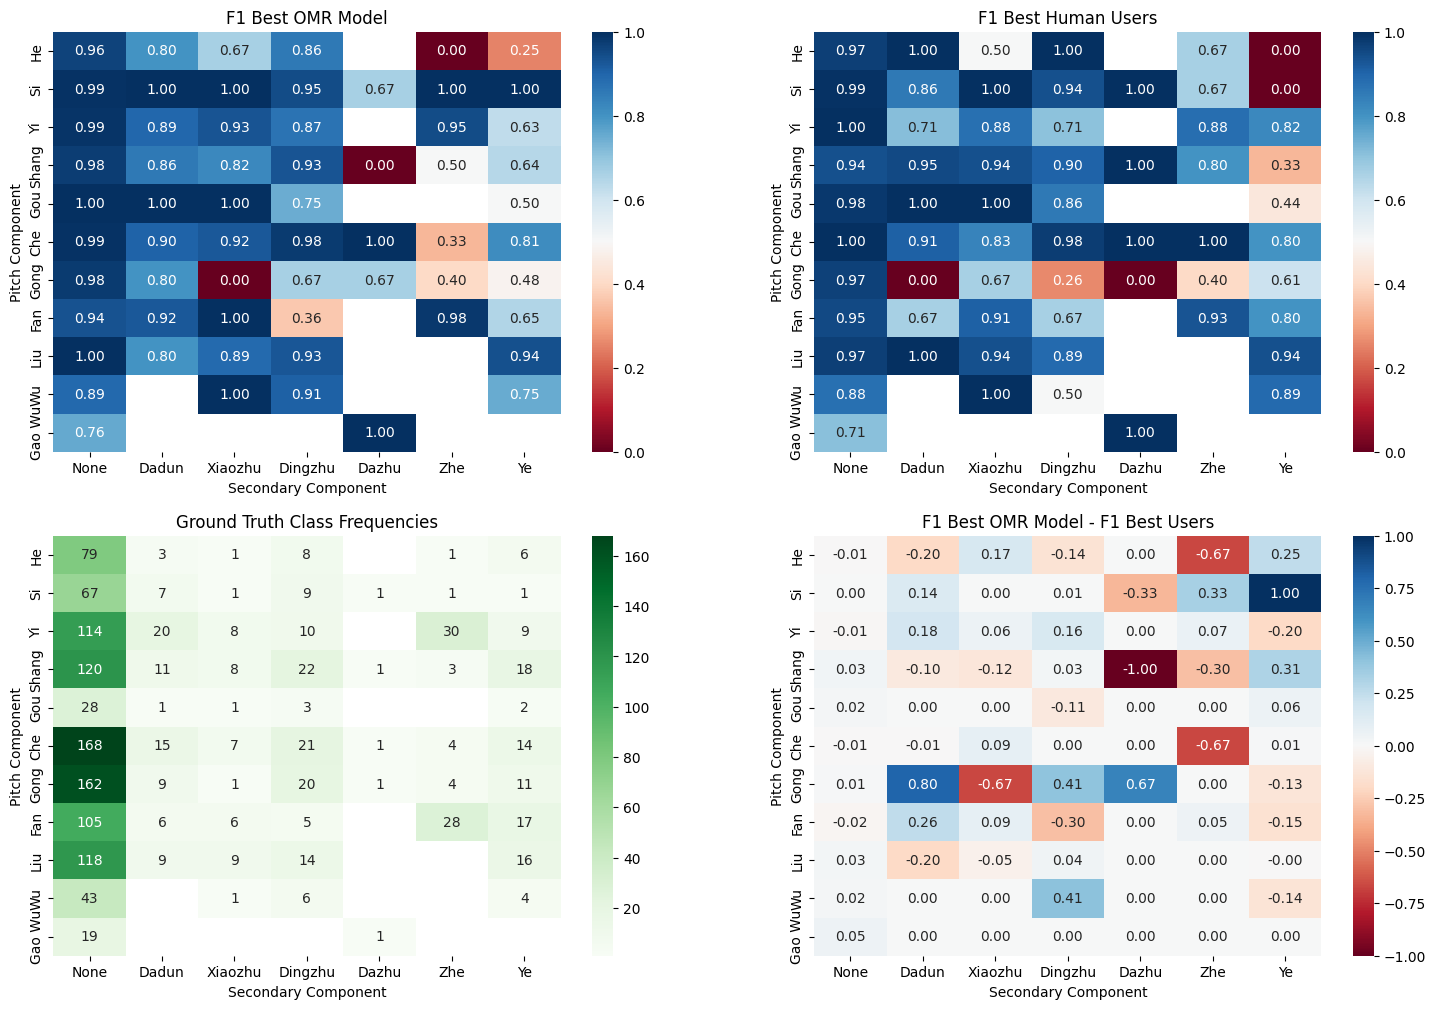

In [265]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plt.title("F1 Best OMR Model")
model_metrics = classification_metrics(ground_truth_classes, prediction_classes, class_labels=range(77))
plt.yticks(np.arange(11)+0.5, ["He", "Si", "Yi", "Shang", "Gou", "Che", "Gong", "Fan", "Liu", "Wu", "Gao Wu"])
plt.xticks(np.arange(7)+0.5, ["None", "Dadun", "Xiaozhu", "Dingzhu", "Dazhu", "Zhe", "Ye"])
plt.ylabel("Pitch Component")
plt.xlabel("Secondary Component")

plt.subplot(2, 2, 2)
plt.title("F1 Best Human Users")
user_metrics = classification_metrics(ground_truth_users_classes, prediction_users_classes, class_labels=range(77))
plt.yticks(np.arange(11)+0.5, ["He", "Si", "Yi", "Shang", "Gou", "Che", "Gong", "Fan", "Liu", "Wu", "Gao Wu"])
plt.xticks(np.arange(7)+0.5, ["None", "Dadun", "Xiaozhu", "Dingzhu", "Dazhu", "Zhe", "Ye"])
plt.ylabel("Pitch Component")
plt.xlabel("Secondary Component")

plt.subplot(2, 2, 3)
plt.title("Ground Truth Class Frequencies")
class_counts = np.bincount(ground_truth_classes, minlength=77)
frequency_grid = np.array(class_counts.reshape(7, 11).transpose())
frequency_grid = 1.*frequency_grid
frequency_grid[frequency_grid==0.] = np.nan
sns.heatmap(frequency_grid, annot=True, cmap='Greens', fmt='.0f')
plt.yticks(np.arange(11)+0.5, ["He", "Si", "Yi", "Shang", "Gou", "Che", "Gong", "Fan", "Liu", "Wu", "Gao Wu"])
plt.xticks(np.arange(7)+0.5, ["None", "Dadun", "Xiaozhu", "Dingzhu", "Dazhu", "Zhe", "Ye"])
plt.ylabel("Pitch Component")
plt.xlabel("Secondary Component")

plt.subplot(2, 2, 4)
diff = model_metrics["f1"]-user_metrics["f1"]
plt.title("F1 Best OMR Model - F1 Best Users")
sns.heatmap(diff, annot=True, cmap='RdBu', fmt='.2f')
plt.yticks(np.arange(11)+0.5, ["He", "Si", "Yi", "Shang", "Gou", "Che", "Gong", "Fan", "Liu", "Wu", "Gao Wu"])
plt.xticks(np.arange(7)+0.5, ["None", "Dadun", "Xiaozhu", "Dingzhu", "Dazhu", "Zhe", "Ye"])
plt.ylabel("Pitch Component")
plt.xlabel("Secondary Component")

plt.savefig("f1-scores.pdf")

0.003036972898984728 0.2734416551945885


<Axes: >

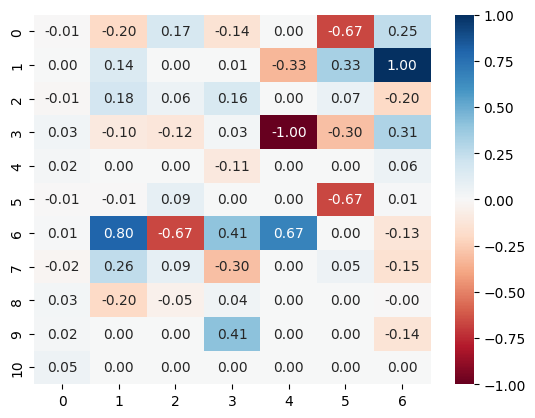

In [248]:

print(np.mean(diff), np.std(diff))
sns.heatmap(diff, annot=True, cmap='RdBu', fmt='.2f')

In [271]:

real_class_idxs = np.logical_not(np.isnan(user_metrics["per_class"]))
print("Model", model_metrics["f1"][real_class_idxs].mean(), model_metrics["f1"][real_class_idxs].std())

real_class_idxs = np.logical_not(np.isnan(model_metrics["per_class"]))
print("User", user_metrics["f1"][real_class_idxs].mean(), user_metrics["f1"][real_class_idxs].std())


Model 0.7911194501104694 0.26001513656260195
User 0.7873477257036657 0.2742295971841971


([<matplotlib.axis.XTick at 0x78a6a3012690>,
 [Text(0.5, 0, 'None'),
  Text(1.5, 0, 'Dadun'),
  Text(2.5, 0, 'Xiaozhu'),
  Text(3.5, 0, 'Dingzhu'),
  Text(4.5, 0, 'Dazhu'),
  Text(5.5, 0, 'Zhe'),
  Text(6.5, 0, 'Ye')])

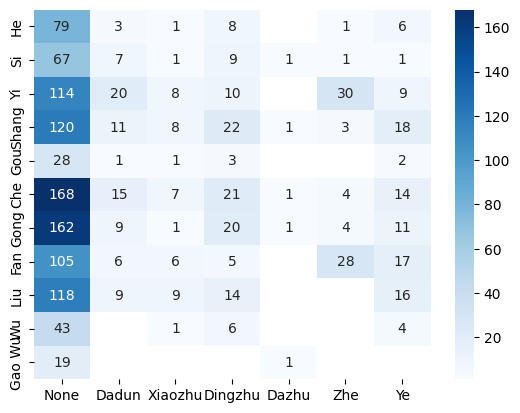

In [225]:


plt.yticks(np.arange(11)+0.5, ["He", "Si", "Yi", "Shang", "Gou", "Che", "Gong", "Fan", "Liu", "Wu", "Gao Wu"])
plt.xticks(np.arange(7)+0.5, ["None", "Dadun", "Xiaozhu", "Dingzhu", "Dazhu", "Zhe", "Ye"])